In [36]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from scipy.sparse import csr_matrix, hstack

# Load the Data and Encode Targets


In [37]:
df = pd.read_csv('ml_challenge_dataset.csv')
print(f"Data shape: {df.shape}")

# Encode target
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df['Painting'])
print("Target classes:", target_encoder.classes_)

Data shape: (1686, 16)
Target classes: ['The Persistence of Memory' 'The Starry Night' 'The Water Lily Pond']


# Clean Numeric Columns
We start by creating some helper functions that will be later be applied to each column

In [38]:
def clean_emotion_intensity(x):
    if pd.isna(x):
        return np.nan
    try:
        return float(x)
    except:
        return np.nan

def clean_count(x):
    if pd.isna(x):
        return np.nan
    x = str(x).replace(',', '').strip()
    match = re.search(r'\d+', x)
    if match:
        return int(match.group())
    else:
        return np.nan

def clean_price(x):
    if pd.isna(x):
        return np.nan
    x = str(x).lower()
    x = x.replace('$', '').replace(',', '').strip()
    multiplier = 1
    if 'million' in x:
        multiplier = 1_000_000
        x = x.replace('million', '')
    elif 'billion' in x:
        multiplier = 1_000_000_000
        x = x.replace('billion', '')
    elif 'k' in x or 'thousand' in x:
        multiplier = 1000
        x = x.replace('k', '').replace('thousand', '')
    numbers = re.findall(r'(\d+(?:\.\d+)?)', x)
    if numbers:
        return float(numbers[0]) * multiplier
    else:
        return np.nan


Now we apply each helper function to clean a specified column.


In [39]:
df['emotion_intensity'] = df["On a scale of 1–10, how intense is the emotion conveyed by the artwork?"].apply(clean_emotion_intensity)
df['prominent_colours'] = df["How many prominent colours do you notice in this painting?"].apply(clean_count)
df['objects_caught'] = df["How many objects caught your eye in the painting?"].apply(clean_count)
df['price_willing'] = df["How much (in Canadian dollars) would you be willing to pay for this painting?"].apply(clean_price)

# Fill missing numeric with median
for col in ['emotion_intensity', 'prominent_colours', 'objects_caught', 'price_willing']:
    median_val = df[col].median(skipna=True)
    df[col] = df[col].fillna(median_val)

Convert Likert scale into numeric values and fill in empty entries with neutral responses.

In [40]:
likert_map = {
    "1 - Strongly disagree": 1,
    "2 - Disagree": 2,
    "3 - Neutral/Unsure": 3,
    "4 - Agree": 4,
    "5 - Strongly agree": 5
}
# Fill in missing entries with a neutral response
for col in ["This art piece makes me feel sombre.", "This art piece makes me feel content.",
            "This art piece makes me feel calm.", "This art piece makes me feel uneasy."]:
    df[col] = df[col].map(likert_map).fillna(3)

# Creating Binary Indicators for Multiple Choice Features

In [41]:
def split_multi(x):
    if pd.isna(x):
        return []
    return [item.strip() for item in str(x).split(',')]

# Room
df['room_list'] = df["If you could purchase this painting, which room would you put that painting in?"].apply(split_multi)
room_categories = set()
for lst in df['room_list']:
    room_categories.update(lst)
room_categories = sorted(room_categories)
for room in room_categories:
    df[f'room_{room}'] = df['room_list'].apply(lambda lst: 1 if room in lst else 0).astype(int)

# Who
df['who_list'] = df["If you could view this art in person, who would you want to view it with?"].apply(split_multi)
who_categories = set()
for lst in df['who_list']:
    who_categories.update(lst)
who_categories = sorted(who_categories)
for who in who_categories:
    df[f'who_{who}'] = df['who_list'].apply(lambda lst: 1 if who in lst else 0).astype(int)

# Season
df['season_list'] = df["What season does this art piece remind you of?"].apply(split_multi)
season_categories = set()
for lst in df['season_list']:
    season_categories.update(lst)
season_categories = sorted(season_categories)
for season in season_categories:
    df[f'season_{season}'] = df['season_list'].apply(lambda lst: 1 if season in lst else 0).astype(int)


# Prepare Text Features to Create a Bag of Words
Combine text features into a single column and fill in empty entries with empty strings.

In [42]:
df['desc'] = df["Describe how this painting makes you feel."].fillna('')
df['food'] = df["If this painting was a food, what would be?"].fillna('')
df['soundtrack'] = df["Imagine a soundtrack for this painting. Describe that soundtrack without naming any objects in the painting."].fillna('')
# Combine each text field into one column; now its ready to be turned into a bag of words
df['all_text'] = df['desc'] + ' ' + df['food'] + ' ' + df['soundtrack']

# Create Training and Validation Sets

In [43]:
X_train_raw, X_val_raw, y_train, y_val = train_test_split(df, y, test_size=0.2, random_state=42, stratify=y)

# Feature Preparation

In [44]:
numeric_cols = ['emotion_intensity', 'prominent_colours', 'objects_caught', 'price_willing',
                'This art piece makes me feel sombre.', 'This art piece makes me feel content.',
                'This art piece makes me feel calm.', 'This art piece makes me feel uneasy.']

# Binary indicator columns: exclude the list columns
binary_cols = [col for col in df.columns if col.startswith(('room_', 'who_', 'season_')) and col not in ['room_list', 'who_list', 'season_list']]
print(f"Number of binary features: {len(binary_cols)}")

# Scale numeric
scaler = StandardScaler()
X_train_numeric = scaler.fit_transform(X_train_raw[numeric_cols]).astype(float)
X_val_numeric = scaler.transform(X_val_raw[numeric_cols]).astype(float)

# Binary (already int)
X_train_binary = X_train_raw[binary_cols].values.astype(int)
X_val_binary = X_val_raw[binary_cols].values.astype(int)

# Text vectorizer
vectorizer = CountVectorizer(max_features=500, min_df=2, stop_words='english')
X_train_text = vectorizer.fit_transform(X_train_raw['all_text'])
X_val_text = vectorizer.transform(X_val_raw['all_text'])

# Combine into sparse matrices
X_train_numeric_sparse = csr_matrix(X_train_numeric)
X_train_binary_sparse = csr_matrix(X_train_binary)
X_train = hstack([X_train_numeric_sparse, X_train_binary_sparse, X_train_text])

X_val_numeric_sparse = csr_matrix(X_val_numeric)
X_val_binary_sparse = csr_matrix(X_val_binary)
X_val = hstack([X_val_numeric_sparse, X_val_binary_sparse, X_val_text])

print(f"Training features shape: {X_train.shape}")

Number of binary features: 14
Training features shape: (1348, 522)


In [54]:
print("\n=== Top 20 words per painting class (training data, bag‑of‑words) ===")
feature_names = vectorizer.get_feature_names_out()
class_names = target_encoder.classes_
for class_id in np.unique(y_train):
    class_mask = (y_train == class_id)
    # Sum word counts for all documents of this painting class
    class_word_counts = X_train_text[class_mask].sum(axis=0).A1
    word_count_series = pd.Series(class_word_counts, index=feature_names)
    top20 = word_count_series.sort_values(ascending=False).head(20)
    print(f"\n{class_names[class_id]}:")
    for word, count in top20.items():
        print(f"  {word}: {int(count)}")


=== Top 20 words per painting class (training data, bag‑of‑words) ===

The Persistence of Memory:
  fall: 308
  thoughts: 291
  love: 262
  late: 216
  ominous: 172
  sit: 171
  rich: 120
  soothing: 101
  far: 62
  somewhat: 58
  mixed: 57
  sandwich: 55
  chill: 53
  uneasy: 49
  peace: 48
  bright: 46
  medium: 46
  know: 42
  positive: 42
  falling: 42

The Starry Night:
  fall: 228
  love: 191
  bright: 190
  late: 133
  ominous: 127
  mixed: 84
  soothing: 79
  peace: 72
  moving: 67
  silent: 54
  bit: 53
  sit: 53
  passage: 52
  positive: 48
  sandwich: 46
  contemplative: 45
  hope: 45
  far: 44
  slower: 40
  somewhat: 38

The Water Lily Pond:
  fall: 215
  bright: 208
  going: 193
  love: 166
  late: 150
  river: 130
  ominous: 113
  passage: 107
  soothing: 93
  mixed: 77
  peace: 69
  motion: 68
  landscape: 66
  real: 66
  slower: 62
  warm: 56
  sit: 54
  uplifting: 48
  songs: 47
  bells: 44


# Train Models using Sklearn
Train naive Bayes, random forest, neural net, and logistic regression models. After training, report that statistics of each model.

In [45]:
# ============================================================
# 8. TRAIN AND EVALUATE MODELS (with train accuracy)
# ============================================================

# Gaussian Naive Bayes
print("\n=== Gaussian Naive Bayes ===")
gnb = GaussianNB()
X_train_dense = X_train.toarray()
X_val_dense = X_val.toarray()
gnb.fit(X_train_dense, y_train)
y_train_pred_gnb = gnb.predict(X_train_dense)
y_val_pred_gnb = gnb.predict(X_val_dense)
print(f"Training accuracy: {accuracy_score(y_train, y_train_pred_gnb):.4f}")
print(f"Validation accuracy: {accuracy_score(y_val, y_val_pred_gnb):.4f}")
print(classification_report(y_val, y_val_pred_gnb, target_names=target_encoder.classes_))

# Random Forest
print("\n=== Random Forest ===")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_train_pred_rf = rf.predict(X_train)
y_val_pred_rf = rf.predict(X_val)
print(f"Training accuracy: {accuracy_score(y_train, y_train_pred_rf):.4f}")
print(f"Validation accuracy: {accuracy_score(y_val, y_val_pred_rf):.4f}")
print(classification_report(y_val, y_val_pred_rf, target_names=target_encoder.classes_))

# MLP Classifier
print("\n=== MLP Classifier ===")
mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42, early_stopping=True, validation_fraction=0.1)
mlp.fit(X_train, y_train)
y_train_pred_mlp = mlp.predict(X_train)
y_val_pred_mlp = mlp.predict(X_val)
print(f"Training accuracy: {accuracy_score(y_train, y_train_pred_mlp):.4f}")
print(f"Validation accuracy: {accuracy_score(y_val, y_val_pred_mlp):.4f}")
print(classification_report(y_val, y_val_pred_mlp, target_names=target_encoder.classes_))

# Logistic Regression
print("\n=== Logistic Regression ===")
lr = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_train_pred_lr = lr.predict(X_train)
y_val_pred_lr = lr.predict(X_val)
print(f"Training accuracy: {accuracy_score(y_train, y_train_pred_lr):.4f}")
print(f"Validation accuracy: {accuracy_score(y_val, y_val_pred_lr):.4f}")
print(classification_report(y_val, y_val_pred_lr, target_names=target_encoder.classes_))


=== Gaussian Naive Bayes ===
Training accuracy: 0.8101
Validation accuracy: 0.7485
                           precision    recall  f1-score   support

The Persistence of Memory       0.84      0.73      0.78       112
         The Starry Night       0.83      0.55      0.66       113
      The Water Lily Pond       0.66      0.96      0.78       113

                 accuracy                           0.75       338
                macro avg       0.77      0.75      0.74       338
             weighted avg       0.77      0.75      0.74       338


=== Random Forest ===
Training accuracy: 0.9770
Validation accuracy: 0.9024
                           precision    recall  f1-score   support

The Persistence of Memory       0.94      0.91      0.92       112
         The Starry Night       0.89      0.83      0.86       113
      The Water Lily Pond       0.89      0.96      0.92       113

                 accuracy                           0.90       338
                macro avg     

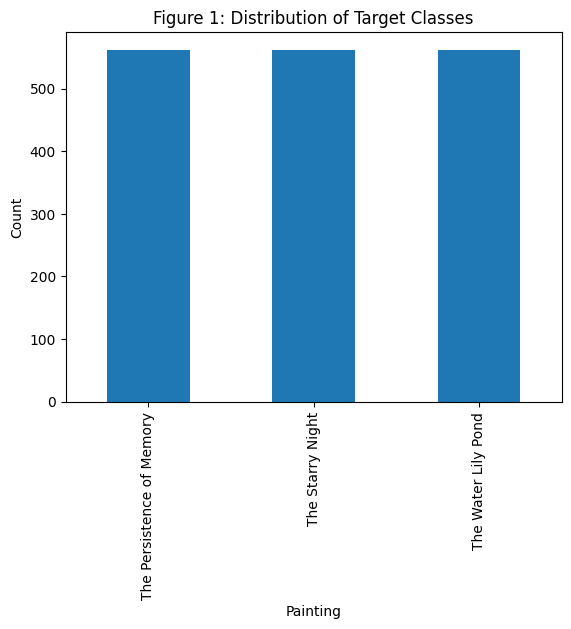

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot target distribution
df['Painting'].value_counts().plot(kind='bar')
plt.title('Figure 1: Distribution of Target Classes')
plt.xlabel('Painting')
plt.ylabel('Count')
plt.show()

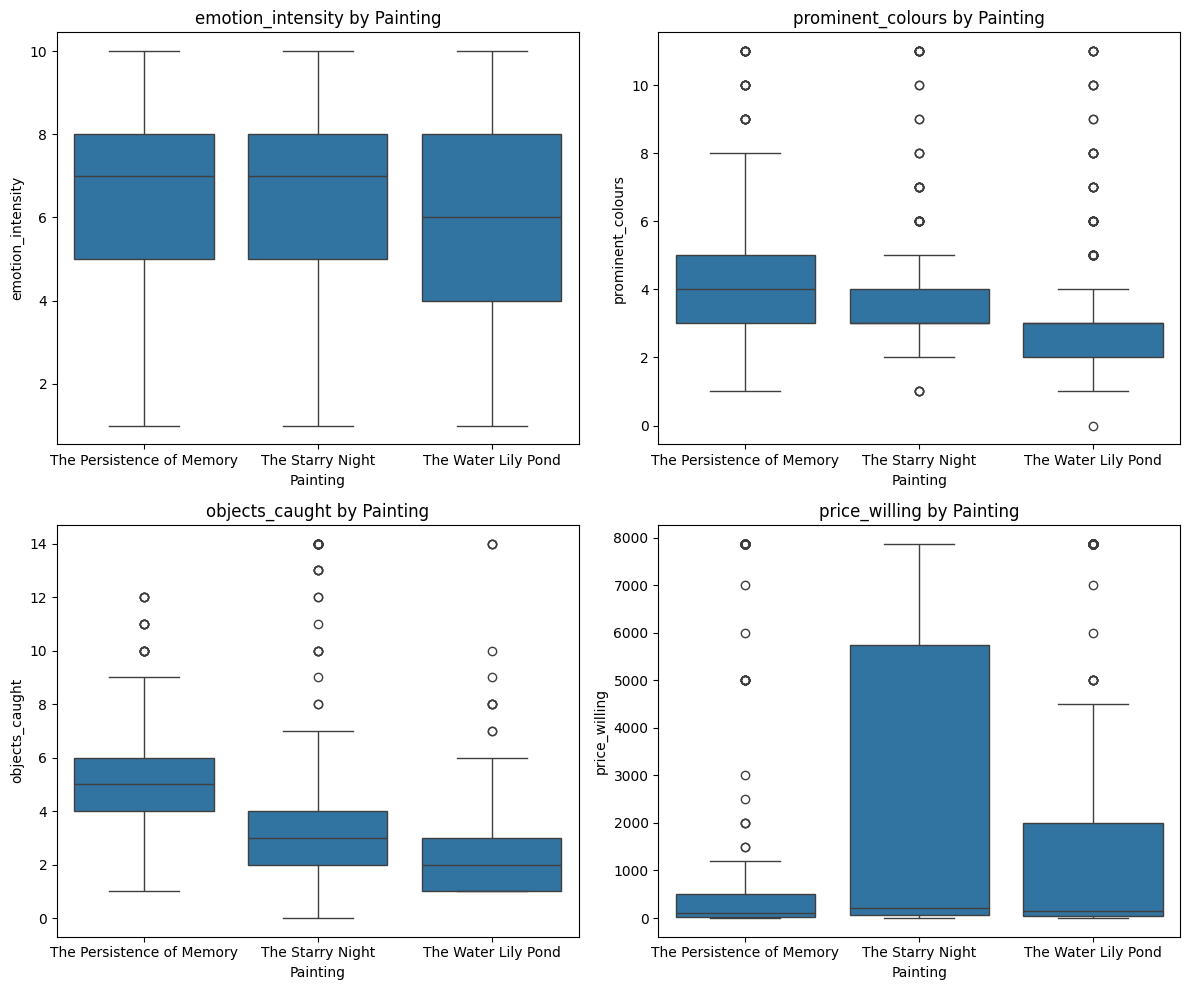

In [48]:
numeric_cols = ['emotion_intensity', 'prominent_colours', 'objects_caught', 'price_willing']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, col in enumerate(numeric_cols):
    sns.boxplot(x='Painting', y=col, data=df, ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'{col} by Painting')
plt.tight_layout()
plt.show()

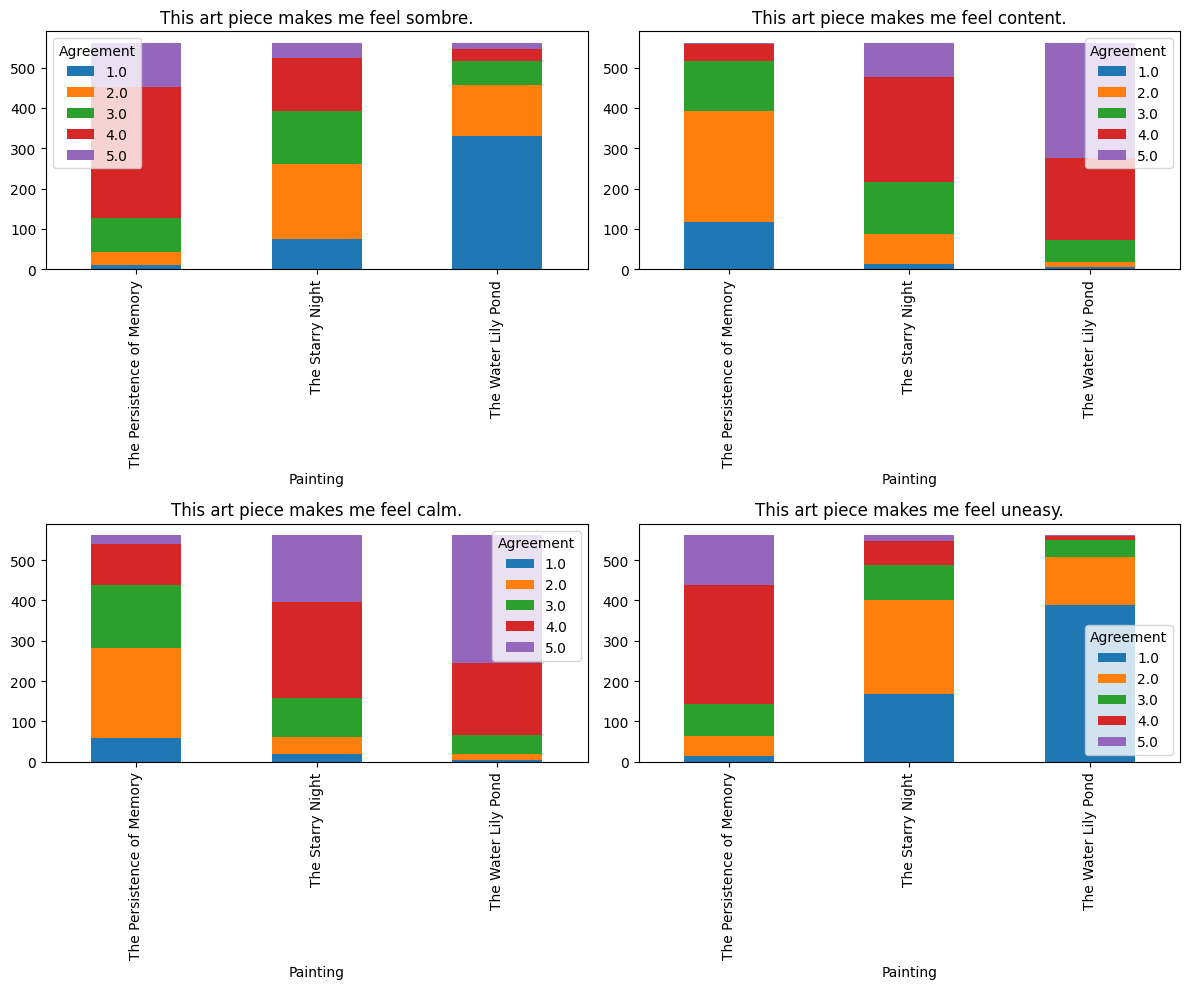

Painting                              The Persistence of Memory  \
This art piece makes me feel sombre.                              
1.0                                                          10   
2.0                                                          32   
3.0                                                          86   
4.0                                                         323   
5.0                                                         111   

Painting                              The Starry Night  The Water Lily Pond  
This art piece makes me feel sombre.                                         
1.0                                                 74                  330  
2.0                                                187                  128  
3.0                                                132                   59  
4.0                                                131                   29  
5.0                                                 38        

In [49]:
likert_cols = [
    "This art piece makes me feel sombre.",
    "This art piece makes me feel content.",
    "This art piece makes me feel calm.",
    "This art piece makes me feel uneasy."
]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, col in enumerate(likert_cols):
    pd.crosstab(df['Painting'], df[col]).plot(kind='bar', stacked=True, ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'{col}')
    axes[i//2, i%2].legend(title='Agreement')
plt.tight_layout()
plt.show()
crosstab = pd.crosstab(df["This art piece makes me feel sombre."], df["Painting"])
print(crosstab)

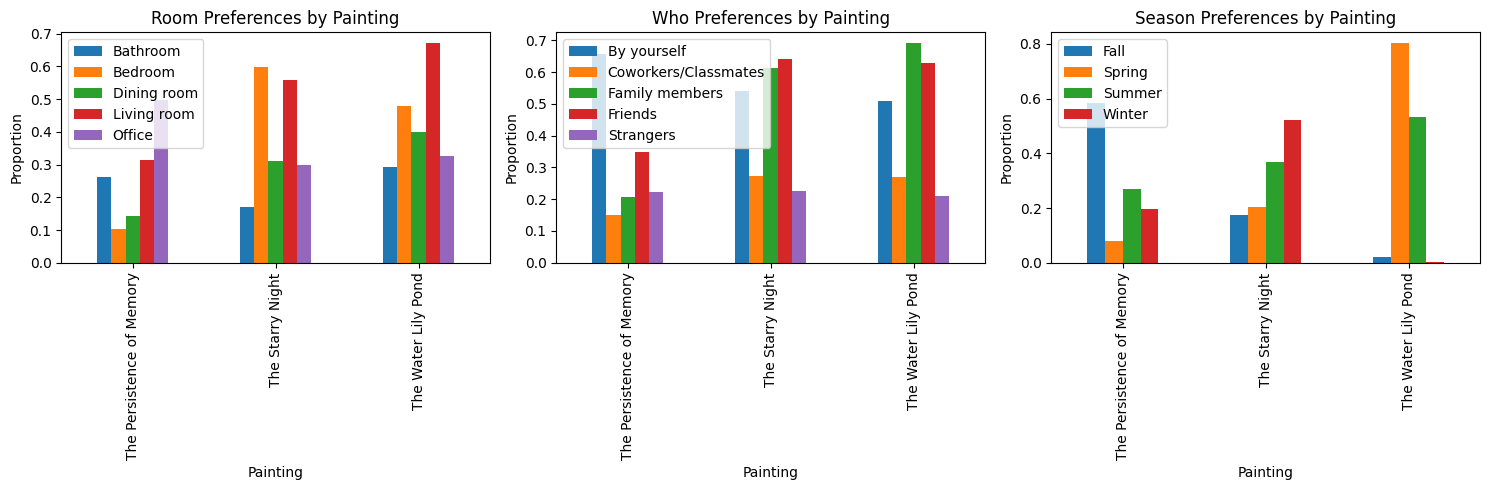

In [50]:
multi_cols = {
    'room': room_categories,
    'who': who_categories,
    'season': season_categories
}
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, (name, cats) in enumerate(multi_cols.items()):
    data = []
    for cat in cats:
        col = f'{name}_{cat}'
        data.append(df.groupby('Painting')[col].mean())
    pd.DataFrame(data, index=cats).T.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'{name.capitalize()} Preferences by Painting')
    axes[i].set_ylabel('Proportion')
plt.tight_layout()
plt.show()